In [ ]:
# === Dependency Installation ===
!pip install Sastrawi gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 30.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.preprocessing import LabelEncoder

from google.colab import drive
drive.mount('/content/drive')

# ganti path sesuai lokasi file kamu
DATA_PATH = "/content/drive/MyDrive/SKRIPSI/dataset.csv"

Mounted at /content/drive


In [ ]:
df = pd.read_csv(DATA_PATH)
print("Jumlah data:", len(df))
df.head(3)

Jumlah data: 150466


,sumber,tanggal,kategori,judul,isi,link,jumlahkata,clean_content
0,kompas.com,7/1/2015,Teknologi,"Ponsel Huawei Honor 4C Dibanderol Rp 2,2 Juta","JAKARTA, KOMPAS.com Ponsel Android Huawei Hon...",http://tekno.kompas.com/read/xml/2015/07/01/18...,315,jakarta kompas com ponsel android huawei honor...
1,kompas.com,7/1/2015,Teknologi,Asosiasi: RPP E-commerce Tidak Sesuai Hasil Di...,"JAKARTA, KOMPAS.com - Sejak 2013, wacana tenta...",http://tekno.kompas.com/read/xml/2015/07/01/16...,419,jakarta kompas com sejak wacana tentang rancan...
2,kompas.com,7/1/2015,Teknologi,"Pemesan ""iPhone Jadi Sabun"" Karyawan Pesaing L...","JAKARTA, KOMPAS.com Danis Darusman, pelanggan ...",http://tekno.kompas.com/read/xml/2015/07/01/15...,265,jakarta kompas com darusman langgan lazada pes...


In [ ]:
df = df[["judul", "isi", "kategori"]]
df.dropna(inplace=True)

print("Jumlah data setelah cleaning:", len(df))
df.head(3)

Jumlah data setelah cleaning: 150466


,judul,isi,kategori
0,"Ponsel Huawei Honor 4C Dibanderol Rp 2,2 Juta","JAKARTA, KOMPAS.com Ponsel Android Huawei Hon...",Teknologi
1,Asosiasi: RPP E-commerce Tidak Sesuai Hasil Di...,"JAKARTA, KOMPAS.com - Sejak 2013, wacana tenta...",Teknologi
2,"Pemesan ""iPhone Jadi Sabun"" Karyawan Pesaing L...","JAKARTA, KOMPAS.com Danis Darusman, pelanggan ...",Teknologi


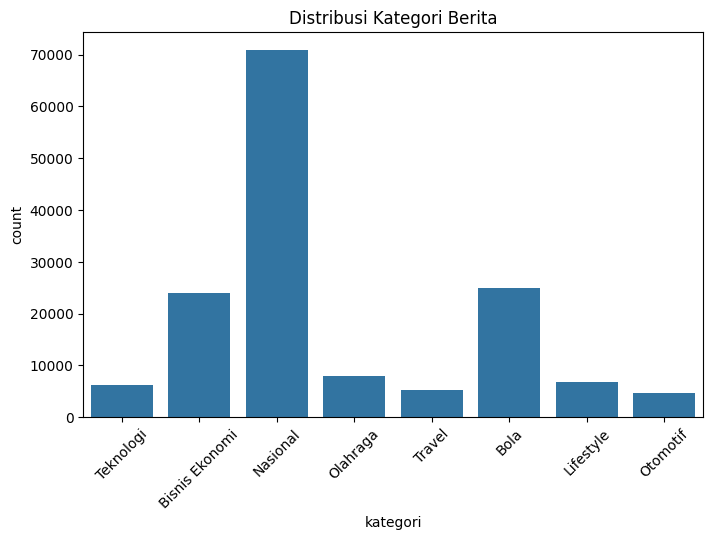

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="kategori")
plt.xticks(rotation=45)
plt.title("Distribusi Kategori Berita")
plt.show()


In [ ]:
df["text"] = df["judul"] + " " + df["isi"]

df[["text"]].head(3)

,text
0,"Ponsel Huawei Honor 4C Dibanderol Rp 2,2 Juta ..."
1,Asosiasi: RPP E-commerce Tidak Sesuai Hasil Di...
2,"Pemesan ""iPhone Jadi Sabun"" Karyawan Pesaing L..."


In [ ]:
def clean_text(text):
    text = text.lower()                            # case folding
    text = re.sub(r'[^a-z\s]', ' ', text)          # hapus simbol & angka
    text = re.sub(r'\s+', ' ', text).strip()       # normalisasi spasi
    return text

df["clean_text"] = df["text"].apply(clean_text)
df[["clean_text"]].head(3)

,clean_text
0,ponsel huawei honor c dibanderol rp juta jakar...
1,asosiasi rpp e commerce tidak sesuai hasil dis...
2,pemesan iphone jadi sabun karyawan pesaing laz...


In [ ]:
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

def remove_stopwords(text):
    return stopword_remover.remove(text)
df["processed_text"] = df["clean_text"].apply(remove_stopwords)
df[["processed_text"]].head(3)

,processed_text
0,ponsel huawei honor c dibanderol rp juta jakar...
1,asosiasi rpp e commerce sesuai hasil diskusi j...
2,pemesan iphone jadi sabun karyawan pesaing laz...


In [ ]:
df["tokens"] = df["processed_text"].apply(lambda x: x.split())
df[["tokens"]].head(3)

,tokens
0,"[ponsel, huawei, honor, c, dibanderol, rp, jut..."
1,"[asosiasi, rpp, e, commerce, sesuai, hasil, di..."
2,"[pemesan, iphone, jadi, sabun, karyawan, pesai..."


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import numpy as np
import pandas as pd

# === 1. Label encoding (kategori -> angka) ===
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["kategori"])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Mapping Label:")
print(label_mapping)

# === 2. Konversi label ke one-hot encoding ===
y_integer = df["label"].values
y = to_categorical(y_integer)
num_classes = y.shape[1]

print("\nJumlah kelas:", num_classes)
print("Urutan kategori (kolom one-hot ke-0 sampai ke-n):", label_encoder.classes_)

# === 3. Tabel one-hot encoding per kategori ===
onehot_table = pd.DataFrame(
    to_categorical(np.arange(num_classes)).astype(int),
    columns=label_encoder.classes_,
    index=label_encoder.classes_
)
onehot_table.index.name = "Kategori"

print("\nTabel One-Hot Encoding:")
display(onehot_table)

# === 4. Contoh penerapan ke data asli ===
sample = df[["processed_text", "kategori", "label"]].head(5).copy()
sample_onehot = pd.DataFrame(
    to_categorical(sample["label"].values, num_classes=num_classes).astype(int),
    columns=label_encoder.classes_,
    index=sample.index
)
sample_result = pd.concat([sample, sample_onehot], axis=1)

print("\nContoh Penerapan One-Hot pada Data:")
display(sample_result)

Mapping Label:
{'Bisnis Ekonomi': np.int64(0), 'Bola': np.int64(1), 'Lifestyle': np.int64(2), 'Nasional': np.int64(3), 'Olahraga': np.int64(4), 'Otomotif': np.int64(5), 'Teknologi': np.int64(6), 'Travel': np.int64(7)}

Jumlah kelas: 8
Urutan kategori (kolom one-hot ke-0 sampai ke-n): ['Bisnis Ekonomi' 'Bola' 'Lifestyle' 'Nasional' 'Olahraga' 'Otomotif'
 'Teknologi' 'Travel']

Tabel One-Hot Encoding:


,Bisnis Ekonomi,Bola,Lifestyle,Nasional,Olahraga,Otomotif,Teknologi,Travel
Kategori,,,,,,,,
Bisnis Ekonomi,1,0,0,0,0,0,0,0
Bola,0,1,0,0,0,0,0,0
Lifestyle,0,0,1,0,0,0,0,0
Nasional,0,0,0,1,0,0,0,0
Olahraga,0,0,0,0,1,0,0,0
Otomotif,0,0,0,0,0,1,0,0
Teknologi,0,0,0,0,0,0,1,0
Travel,0,0,0,0,0,0,0,1



Contoh Penerapan One-Hot pada Data:


,processed_text,kategori,label,Bisnis Ekonomi,Bola,Lifestyle,Nasional,Olahraga,Otomotif,Teknologi,Travel
0,ponsel huawei honor c dibanderol rp juta jakar...,Teknologi,6,0,0,0,0,0,0,1,0
1,asosiasi rpp e commerce sesuai hasil diskusi j...,Teknologi,6,0,0,0,0,0,0,1,0
2,pemesan iphone jadi sabun karyawan pesaing laz...,Teknologi,6,0,0,0,0,0,0,1,0
3,autofeather failure momok pesawat baling balin...,Teknologi,6,0,0,0,0,0,0,1,0
4,laptop bezel tertipis dunia masuk indonesia ja...,Teknologi,6,0,0,0,0,0,0,1,0


In [ ]:
import json

SAVE_PATH = "/content/drive/MyDrive/SKRIPSI/dataset_preprocessed.csv"

df_to_save = df[["processed_text", "tokens", "kategori", "label"]].copy()
df_to_save["tokens"] = df_to_save["tokens"].apply(json.dumps)  # list -> string JSON aman

df_to_save.to_csv(SAVE_PATH, index=False)
print("File preprocessing tersimpan:", SAVE_PATH)

File preprocessing tersimpan: /content/drive/MyDrive/SKRIPSI/dataset_preprocessed.csv
